In [1]:
%load_ext autoreload
%autoreload 2

# Outside Travel Widget - Events Analysis

Exploratory analysis of the travel booking widget embedded across partner sites.

**Data source:** S3 (`s3://outside-rudderstack-prod/rudder-logs/35OVW4ziaxPwbNqNO2nlCKaU6lx/`)

**Event types:**
- `Loaded a Page` — iframe page load
- `Embed Widget Viewed` — widget impression
- `Travel Searched` — user searched for a destination
- `Property Added to Cart` — user added a property
- `Checkout Clicked` — user clicked checkout
- `Search Refined` — user refined their search
- `No Availability Viewed` / `No Availability Exited` — no results flow

In [2]:
import sys
sys.path.insert(0, '..')

from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from travel_events.loader import load_day, load_date_range
from travel_events import analysis

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 80)

## 1. Load Data

Adjust the date range as needed. Start small (a few days) to test, then expand.

In [3]:
# Load a week of recent data
df = load_date_range(date(2026, 2, 16), date(2026, 3, 16))
print(f'Loaded {len(df):,} events from {df["timestamp"].min()} to {df["timestamp"].max()}')
df.head()

Loading 2026-02-16 (cache)
Loading 2026-02-17 (cache)
Loading 2026-02-18 (cache)
Loading 2026-02-19 (cache)
Loading 2026-02-20 (cache)
Loading 2026-02-21 (cache)
Loading 2026-02-22 (cache)
Loading 2026-02-23 (cache)
Loading 2026-02-24 (cache)
Loading 2026-02-25 (cache)
Loading 2026-02-26 (cache)
Loading 2026-02-27 (cache)
Loading 2026-02-28 (cache)
Loading 2026-03-01 (cache)
Loading 2026-03-02 (cache)
Loading 2026-03-03 (cache)
Loading 2026-03-04 (cache)
Loading 2026-03-05 (cache)
Loading 2026-03-06 (cache)
Loading 2026-03-07 (cache)
Loading 2026-03-08 (cache)
Loading 2026-03-09 (cache)
Loading 2026-03-10 (cache)
Loading 2026-03-11 (cache)
Loading 2026-03-12 (cache)
Loading 2026-03-13 (cache)
Loading 2026-03-14 (cache)
Loading 2026-03-15 (cache)
Loading 2026-03-16 (cache)
Loaded 116,459 events from 2026-01-15 23:09:29.834000+00:00 to 2026-03-16 23:59:44.645000+00:00


,event,type,anonymous_id,message_id,timestamp,received_at,request_ip,session_id,session_start,user_agent,locale,timezone,screen_width,screen_height,page_url,...,search_text,arrival_date,departure_date,number_of_adults,number_of_children,search_surface,property_id,search_type,user_id,refinement_type,supplier_id,product_id,quantity,exit_type,time_since_no_availability_ms
0,Embed Widget Viewed,track,1fadeb62-028f-4b50-ac5b-1dad9370646b,fac13649-9c91-4ce9-8ea6-fb6ebf02e257,2026-02-16 00:00:10.806000+00:00,2026-02-16 00:00:10.806000+00:00,71.192.206.245,1.771200e+12,True,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like Mac OS X) AppleWebKit/605.1.1...,en-US,GMT-0500,390,844,https://travel.outsideonline.com/embed?utm_source=RunReg&utm_campaign=RunReg...,...,None,None,None,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Loaded a Page,track,1fadeb62-028f-4b50-ac5b-1dad9370646b,4225c09a-e882-4561-9c40-964f5138aa8f,2026-02-16 00:00:10.806000+00:00,2026-02-16 00:00:10.806000+00:00,71.192.206.245,1.771200e+12,True,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like Mac OS X) AppleWebKit/605.1.1...,en-US,GMT-0500,390,844,https://travel.outsideonline.com/embed?utm_source=RunReg&utm_campaign=RunReg...,...,None,None,None,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Loaded a Page,track,1bc01abe-bbc3-4892-8fd5-928f401a18ed,de2821e9-3233-46db-a7a1-0de0b31508d9,2026-02-16 00:03:41.272000+00:00,2026-02-16 00:03:41.273000+00:00,69.14.37.0,1.771200e+12,True,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2_1 like Mac OS X) AppleWebKit/605.1.1...,en-US,GMT-0500,414,896,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,...,None,None,None,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Embed Widget Viewed,track,1bc01abe-bbc3-4892-8fd5-928f401a18ed,aff75fb5-6c55-424b-a6a6-75925b2350d1,2026-02-16 00:03:41.272000+00:00,2026-02-16 00:03:41.273000+00:00,69.14.37.0,1.771200e+12,True,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2_1 like Mac OS X) AppleWebKit/605.1.1...,en-US,GMT-0500,414,896,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,...,None,None,None,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Loaded a Page,track,54f44b5b-42b3-4b06-8301-306cc466a9b2,16295788-0f00-49c1-8480-06db4448178d,2026-02-16 00:02:38.453000+00:00,2026-02-16 00:02:38.454000+00:00,104.28.50.173,1.771200e+12,True,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 ...,en-US,GMT-0600,414,896,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,...,None,None,None,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data quality: which days have all-NA columns?

In [4]:
# Which columns are entirely NA across the full dataset?
all_na_cols = df.columns[df.isna().all()].tolist()
print(f"Columns that are entirely NA across all {len(df):,} events:")
print(all_na_cols if all_na_cols else "  (none)")
print()

# Check per-day: which days have columns that are all-NA?
df_copy = df.copy()
df_copy['_date'] = df_copy['timestamp'].dt.date
for day, group in df_copy.groupby('_date'):
    na_cols = group.columns[group.isna().all()].tolist()
    na_cols = [c for c in na_cols if c != '_date']
    if na_cols:
        print(f"  {day} ({len(group):,} events): all-NA columns → {na_cols}")

Columns that are entirely NA across all 116,459 events:
  (none)

  2026-01-15 (2 events): all-NA columns → ['utm_term', 'variant', 'search_text', 'arrival_date', 'departure_date', 'number_of_adults', 'number_of_children', 'search_surface', 'property_id', 'search_type', 'user_id', 'refinement_type', 'supplier_id', 'product_id', 'quantity', 'exit_type', 'time_since_no_availability_ms']
  2026-01-21 (1 events): all-NA columns → ['utm_term', 'variant', 'has_custom_header', 'search_text', 'arrival_date', 'departure_date', 'number_of_adults', 'number_of_children', 'property_id', 'search_type', 'user_id', 'refinement_type', 'supplier_id', 'product_id', 'quantity']
  2026-02-09 (6 events): all-NA columns → ['search_text', 'arrival_date', 'departure_date', 'number_of_adults', 'number_of_children', 'search_surface', 'property_id', 'search_type', 'user_id', 'refinement_type', 'supplier_id', 'product_id', 'quantity', 'exit_type', 'time_since_no_availability_ms']
  2026-02-12 (2 events): all-NA co

## 2. Event Summary

In [5]:
summary = analysis.event_summary(df)
summary

,count,unique_users,registered_users,anonymous_users
event,,,,
Loaded a Page,58493,46365,14,46359
Embed Widget Viewed,57596,46083,2,46081
Travel Searched,126,74,7,66
No Availability Viewed,30,24,0,24
Embed Widget Clicked,27,26,0,26
Property Added to Cart,22,18,2,16
Checkout Clicked,15,13,2,11
No Availability Exited,12,11,0,11
Search Refined,9,8,0,8


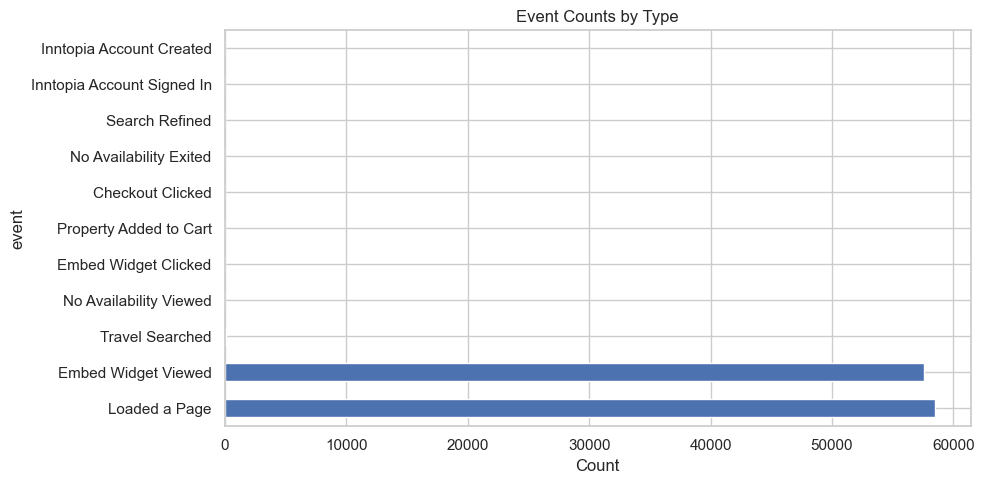

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
summary['count'].plot(kind='barh', ax=ax)
ax.set_title('Event Counts by Type')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 3. Daily Trends

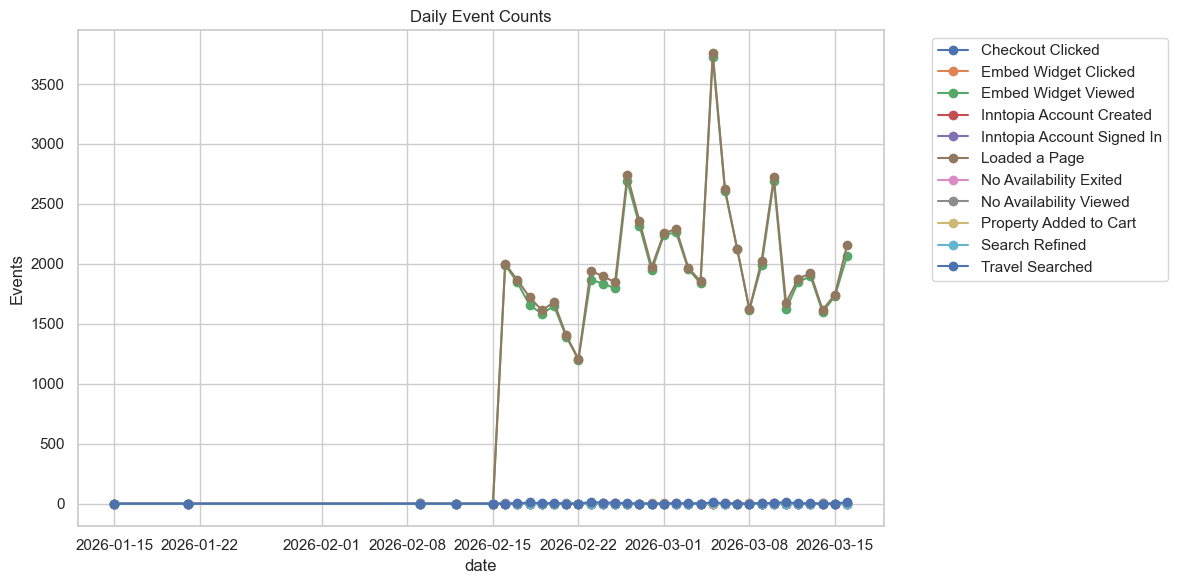

In [7]:
daily = analysis.daily_event_counts(df)

fig, ax = plt.subplots(figsize=(12, 6))
daily.plot(ax=ax, marker='o')
ax.set_title('Daily Event Counts')
ax.set_ylabel('Events')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Conversion Funnel

In [25]:
funnel_df = analysis.funnel(df)
funnel_df

,step,events,unique_users,conversion_rate
0,Loaded a Page,58493,46365,100.00
1,Embed Widget Viewed,57596,46083,99.39
2,Embed Widget Clicked,27,26,0.06
3,Travel Searched,126,74,0.16
4,Property Added to Cart,22,18,0.04
5,Checkout Clicked,15,13,0.03


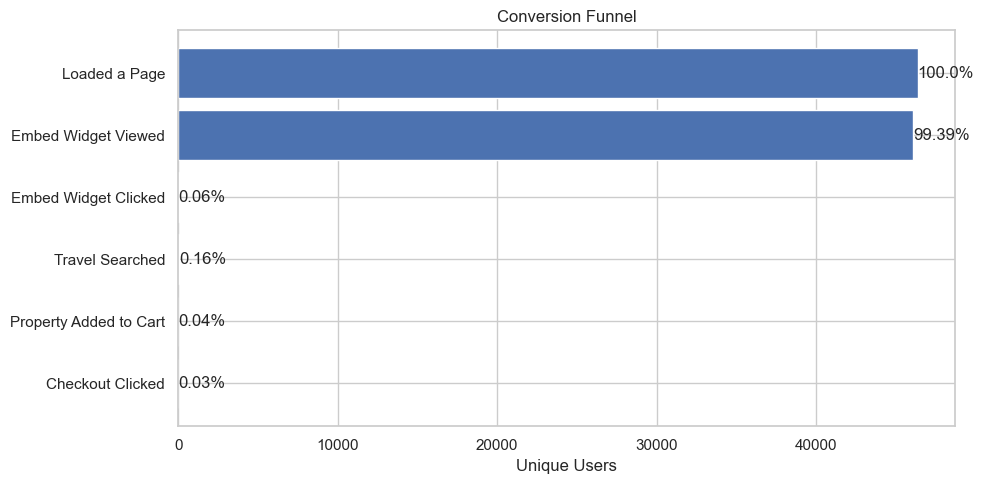

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(funnel_df['step'], funnel_df['unique_users'])
for i, row in funnel_df.iterrows():
    ax.text(row['unique_users'] + 1, i, f"{row['conversion_rate']}%", va='center')
ax.set_xlabel('Unique Users')
ax.set_title('Conversion Funnel')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. UTM Source / Campaign Breakdown

In [26]:
# Verify: UTM breakdown counts ALL event types per source, not just one
# BikeReg events broken out by event type:
bikereg = df[df['utm_source'] == 'BikeReg']
print(f"BikeReg total events: {len(bikereg):,}")
print()
print("BikeReg events by type:")
print(bikereg['event'].value_counts())

BikeReg total events: 62,179

BikeReg events by type:
event
Loaded a Page             31096
Embed Widget Viewed       31071
Embed Widget Clicked          7
No Availability Viewed        3
No Availability Exited        2
Name: count, dtype: int64


In [27]:
utm = analysis.utm_breakdown(df)
utm.head(20)

impressions  \
utm_source          utm_campaign                                                                                  
BikeReg             BikeRegConfirmation                                                                   31096   
SkiReg              SkiRegConfirmation                                                                     7529   
RunReg              RunRegConfirmation                                                                     6861   
National Park Trips 5 Best Colorado Mountain Towns, According to a Local                                   4756   
SKI                 Where to Stay in Banff                                                                 1307   
TriReg              TriRegConfirmation                                                                      825   
Outside             Skiing with Beginners? Check Out These 8 Resorts Offering Perks For New Skiers          456   
                    Aspen Has Been Overrun by Zillionaires. Has the Town Lost Its Gonzo Soul?               195   
SKI                 Everything I Wish I Knew Before Visiting Taos Ski Valley                                 24   
                    Where to Stay in Park City                                                               23   
                    Editors' Guide to the Best Places to Stay in Telluride                                   16   
                    Where to Stay in Aspen                                                                   14   
                    Where to Stay in Vail                                                                     4   
ski_mag             Banff                                                                                     3   
SKI                 ski                                                                                       1   
Climbing            tk tk                                                                                     1   
SKI                 A Ski Traveler's Guide to Winter Park                                                     1   
                    Stowe Email                                                                               0   

                                                                                                    widget_views  \
utm_source          utm_campaign                                                                                   
BikeReg             BikeRegConfirmation                                                                    31071   
SkiReg              SkiRegConfirmation                                                                      7505   
RunReg              RunRegConfirmation                                                                      6860   
National Park Trips 5 Best Colorado Mountain Towns, According to a Local                                    4770   
SKI                 Where to Stay in Banff                                                                  1300   
TriReg              TriRegConfirmation                                                                       825   
Outside             Skiing with Beginners? Check Out These 8 Resorts Offering Perks For New Skiers           456   
                    Aspen Has Been Overrun by Zillionaires. Has the Town Lost Its Gonzo Soul?                196   
SKI                 Everything I Wish I Knew Before Visiting Taos Ski Valley                                   0   
                    Where to Stay in Park City                                                                23   
                    Editors' Guide to the Best Places to Stay in Telluride                                     0   
                    Where to Stay in Aspen                                                                    14   
                    Where to Stay in Vail                                                                      4   
ski_mag             Banff                                  

## 6. Referrer Analysis

In [28]:
refs = analysis.referrer_breakdown(df)
refs.head(20)

,events,unique_users,widget_views
traffic_source,,,
BikeReg,62165,27160,31082
SkiReg,14881,5835,7437
RunReg,13715,6243,6857
SKI,6487,2373,3217
(direct),5949,1986,2610
National Park Trips,5198,918,2600
www.mycoloradoparks.com,4191,618,2100
TriReg,1366,637,683
www.outsideonline.com,1303,330,649


### Investigating empty referring_domain

In [29]:
# Check the actual values - are some empty strings?
print("Top referring_domain values:")
print(df['referring_domain'].value_counts().head(20))
print()
print(f"Empty string count: {(df['referring_domain'] == '').sum():,}")

Top referring_domain values:
referring_domain
                                49427
www.bikereg.com                 37560
www.skireg.com                   9130
www.runreg.com                   7846
www.skimag.com                   4944
www.mycoloradoparks.com          4191
www.outsideonline.com            1303
www.trireg.com                    866
travel.outsideonline.com          416
dev.trireg.com                    284
dev.skireg.com                    139
cdn.mycoloradoparks.com           126
dev.bikereg.com                    50
www.google.com                     47
statics.teams.cdn.office.net       40
cdn.skimag.com                     36
dev.runreg.com                     14
localhost:44343                    14
www.inntopia.travel                 7
www.facebook.com                    6
Name: count, dtype: int64

Empty string count: 49,427


## Events with empty-string referring_domain - show all potentially useful columns

In [13]:
empty_ref = df[df['referring_domain'] == '']
print(f"Events with empty referring_domain: {len(empty_ref):,}")
print()
empty_ref[['event', 'page_url', 'page_path', 'page_title', 'referrer', 'referring_domain',
           'utm_source', 'utm_campaign', 'utm_content', 'utm_term',
           'domain', 'variant', 'request_ip', 'user_agent', 'anonymous_id', 'user_id']].head(15)

Events with empty referring_domain: 49,427



,event,page_url,page_path,page_title,referrer,referring_domain,utm_source,utm_campaign,utm_content,utm_term,domain,variant,request_ip,user_agent,anonymous_id,user_id
2,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,/embed,Outside - Discover Your Next Adventure,$direct,,SkiReg,SkiRegConfirmation,Travel Booking Widget,Lodging Near Boyne Falls,travel.outsideonline.com,None,69.14.37.0,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2_1 like Mac OS X) AppleWebKit/605.1.1...,1bc01abe-bbc3-4892-8fd5-928f401a18ed,NaN
3,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,/embed,Outside - Discover Your Next Adventure,$direct,,SkiReg,SkiRegConfirmation,Travel Booking Widget,Lodging Near Boyne Falls,travel.outsideonline.com,a,69.14.37.0,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2_1 like Mac OS X) AppleWebKit/605.1.1...,1bc01abe-bbc3-4892-8fd5-928f401a18ed,NaN
4,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,Outside - Discover Your Next Adventure,$direct,,BikeReg,BikeRegConfirmation,Travel Booking Widget,Lodging Near Muenster,travel.outsideonline.com,None,104.28.50.173,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 ...,54f44b5b-42b3-4b06-8301-306cc466a9b2,NaN
7,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,Outside - Discover Your Next Adventure,$direct,,BikeReg,BikeRegConfirmation,Travel Booking Widget,Lodging Near Patagonia,travel.outsideonline.com,None,73.3.98.176,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2_1 like Mac OS X) AppleWebKit/605.1.1...,ec045add-6e65-4eb2-a3a7-006fdbfccb05,NaN
8,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,Outside - Discover Your Next Adventure,$direct,,BikeReg,BikeRegConfirmation,Travel Booking Widget,Lodging Near Patagonia,travel.outsideonline.com,a,73.3.98.176,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2_1 like Mac OS X) AppleWebKit/605.1.1...,ec045add-6e65-4eb2-a3a7-006fdbfccb05,NaN
9,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Vail&source=SKI&campaign=Where+...,/embed,Outside - Discover Your Next Adventure,$direct,,None,None,Travel Booking Widget,None,travel.outsideonline.com,b,72.81.251.56,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2 like Mac OS X) AppleWebKit/605.1.15 ...,5f36d08f-5b05-413b-bf37-f47905222e4b,NaN
10,Loaded a Page,https://travel.outsideonline.com/embed?query=Vail&source=SKI&campaign=Where+...,/embed,Outside - Discover Your Next Adventure,$direct,,None,None,Travel Booking Widget,None,travel.outsideonline.com,None,72.81.251.56,Mozilla/5.0 (iPhone; CPU iPhone OS 26_2 like Mac OS X) AppleWebKit/605.1.15 ...,5f36d08f-5b05-413b-bf37-f47905222e4b,NaN
13,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,Outside - Discover Your Next Adventure,$direct,,BikeReg,BikeRegConfirmation,Travel Booking Widget,Lodging Near Birmingham,travel.outsideonline.com,None,108.250.131.222,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 ...,f789ca62-4b4d-4751-a685-bf8d06686e94,NaN
14,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,Outside - Discover Your Next Adventure,$direct,,BikeReg,BikeRegConfirmation,Travel Booking Widget,Lodging Near Birmingham,travel.outsideonline.com,a,108.250.131.222,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 ...,f789ca62-4b4d-4751-a685-bf8d06686e94,NaN
15,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,/embed,Outside - Discover Your Next Adventure,$direct,,SkiReg,SkiRegConfirmation,Travel Booking Widget,Lodging Near Wakefield,travel.outsideonline.com,None,104.28.103.64,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 ...,ee4c19f0-9d28-4f35-87bd-719b188bb60f,NaN


In [14]:
# Compare: what do events WITH a referring_domain look like?
has_ref = df[df['referring_domain'].notna()]
print(f"Sample events with referring_domain ({len(has_ref):,} total):")
has_ref[['event', 'page_url', 'page_path', 'referrer', 'referring_domain', 'utm_source', 'domain', 'anonymous_id']].head(10)

Sample events with referring_domain (116,459 total):


,event,page_url,page_path,referrer,referring_domain,utm_source,domain,anonymous_id
0,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=RunReg&utm_campaign=RunReg...,/embed,https://www.runreg.com/,www.runreg.com,RunReg,travel.outsideonline.com,1fadeb62-028f-4b50-ac5b-1dad9370646b
1,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=RunReg&utm_campaign=RunReg...,/embed,https://www.runreg.com/,www.runreg.com,RunReg,travel.outsideonline.com,1fadeb62-028f-4b50-ac5b-1dad9370646b
2,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,/embed,$direct,,SkiReg,travel.outsideonline.com,1bc01abe-bbc3-4892-8fd5-928f401a18ed
3,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=SkiReg&utm_campaign=SkiReg...,/embed,$direct,,SkiReg,travel.outsideonline.com,1bc01abe-bbc3-4892-8fd5-928f401a18ed
4,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,$direct,,BikeReg,travel.outsideonline.com,54f44b5b-42b3-4b06-8301-306cc466a9b2
5,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,https://www.bikereg.com/,www.bikereg.com,BikeReg,travel.outsideonline.com,9105f753-eb4a-4e87-9f05-c339d819482b
6,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,https://www.bikereg.com/,www.bikereg.com,BikeReg,travel.outsideonline.com,9105f753-eb4a-4e87-9f05-c339d819482b
7,Loaded a Page,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,$direct,,BikeReg,travel.outsideonline.com,ec045add-6e65-4eb2-a3a7-006fdbfccb05
8,Embed Widget Viewed,https://travel.outsideonline.com/embed?utm_source=BikeReg&utm_campaign=BikeR...,/embed,$direct,,BikeReg,travel.outsideonline.com,ec045add-6e65-4eb2-a3a7-006fdbfccb05
9,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Vail&source=SKI&campaign=Where+...,/embed,$direct,,None,travel.outsideonline.com,5f36d08f-5b05-413b-bf37-f47905222e4b


In [15]:
destinations = analysis.top_search_destinations(df)
destinations.head(20)

,count,unique_users
search_text,,
"Aspen, CO, USA",52,34
"Banff, AB, Canada",29,21
"Avon, CO, USA",10,9
"Breckenridge, CO, USA",8,5
"Stowe, VT, USA",6,4
"Beaver Creek, CO, USA",5,5
"Canmore, AB, Canada",3,3
"Killington, VT, USA",3,3
"Steamboat Springs, CO, USA",3,3


## UTM Term vs Search Text Exploration

In [16]:
# utm_term overview
print(f"Events with utm_term: {df['utm_term'].notna().sum():,} / {len(df):,}")
print(f"Events with search_text: {df['search_text'].notna().sum():,} / {len(df):,}")
print()
print("Top utm_term values:")
print(df['utm_term'].value_counts().head(20))
print()
print("Top search_text values:")
print(df['search_text'].value_counts().head(20))

Events with utm_term: 92,993 / 116,459
Events with search_text: 165 / 116,459

Top utm_term values:
utm_term
Lodging Near Boston               2124
Lodging Near Gilford              1515
Lodging Near Manchester           1258
Lodging Near Fayetteville, AR     1212
Lodging Near Greenville           1172
Lodging Near Redlands             1164
Lodging Near Athens               1124
Lodging Near Zirconia             1120
Lodging Near Frisco               1110
Lodging Near Georgetown           1090
Lodging Near Portsmouth           1042
Lodging Near Port Angeles         1040
Lodging Near Dover                 944
Lodging Near Santa Rosa            918
Lodging Near North Logan           912
Lodging Near Upper Marlboro        892
Lodging Near Plymouth              854
Lodging Near Baytown               838
Lodging Near Langley Twp           764
Lodging Near Bloomington           761
Name: count, dtype: int64

Top search_text values:
search_text
Aspen, CO, USA                     53
Banff, AB,

## 8. Engaged Users

All users who saw or interacted with the travel widget, with their engagement summary.

In [17]:
# Do utm_term and search_text ever appear on the same event?
has_both = df[df['utm_term'].notna() & df['search_text'].notna()]
print(f"Events with BOTH utm_term and search_text: {len(has_both):,}")
if not has_both.empty:
    print()
    print(has_both[['event', 'utm_term', 'search_text', 'utm_source', 'utm_campaign']].head(10))

print()
# What event types carry utm_term?
print("Event types with utm_term:")
print(df[df['utm_term'].notna()].groupby('event').size().sort_values(ascending=False))
print()
# What event types carry search_text?
print("Event types with search_text:")
print(df[df['search_text'].notna()].groupby('event').size().sort_values(ascending=False))

Events with BOTH utm_term and search_text: 9

                         event                            utm_term  \
945     No Availability Viewed         Lodging Near Aspen Snowmass   
948     No Availability Viewed         Lodging Near Aspen Snowmass   
9788    No Availability Viewed                 Lodging Near Frisco   
13066   No Availability Viewed                  Lodging Near Aspen   
19656   No Availability Viewed  Lodging Near Holiday Valley Resort   
24558   No Availability Viewed                 Lodging Near Frisco   
94126   No Availability Viewed            Lodging Near Winter Park   
94357   No Availability Viewed            Lodging Near Winter Park   
103811  No Availability Viewed             Lodging Near Angel Fire   

                            search_text utm_source         utm_campaign  
945               Limelight Hotel Aspen     SkiReg   SkiRegConfirmation  
948     St. Moritz Lodge & Condominiums     SkiReg   SkiRegConfirmation  
9788                    Copper 

In [18]:
users = analysis.engaged_users(df)
print(f'Total engaged users: {len(users):,}')
users.head(20)

Total engaged users: 46,176


,first_seen,last_seen,total_events,widget_views,widget_clicks,searches,cart_adds,checkouts,sessions,utm_sources,referrers,request_ips,max_funnel_step
anonymous_id,,,,,,,,,,,,,
0ff770ac-8956-4c3d-b6b6-984719b76281,2026-03-05 23:41:32.969000+00:00,2026-03-16 22:28:54.007000+00:00,75,75,0,0,0,0,25,National Park Trips,www.mycoloradoparks.com,"69.54.23.179, 67.2.252.149",Embed Widget Viewed
150bd674-f26f-4e11-afdc-1c2052f7dc03,2026-02-27 20:25:17.365000+00:00,2026-03-12 13:42:30.308000+00:00,45,45,0,0,0,0,5,National Park Trips,"cdn.mycoloradoparks.com, www.mycoloradoparks.com",4.4.233.24,Embed Widget Viewed
c46d92d8-7a0b-4d35-9215-8a10ba251483,2026-02-27 18:07:42.654000+00:00,2026-03-10 15:50:20.261000+00:00,45,45,0,0,0,0,4,National Park Trips,"cdn.mycoloradoparks.com, www.mycoloradoparks.com",72.196.138.112,Embed Widget Viewed
fec81913-eba0-4c45-a2e4-58fd00e65e61,2026-02-16 14:40:28.697000+00:00,2026-03-12 16:37:01.853000+00:00,44,44,0,0,0,0,23,RunReg,www.runreg.com,"147.206.1.29, 147.206.1.23",Embed Widget Viewed
725eeced-d72d-493f-bf4c-ae9f46a6b07f,2026-02-25 19:38:33.680000+00:00,2026-03-16 13:49:40.831000+00:00,32,32,0,0,0,0,4,SKI,www.skimag.com,"23.151.240.73, 23.151.240.238",Embed Widget Viewed
0653bbfa-c9e0-46ca-baa8-5bda11b1fddc,2026-02-23 17:35:24.039000+00:00,2026-03-16 17:56:37.546000+00:00,25,25,0,0,0,0,15,SKI,www.skimag.com,"108.4.243.171, 71.162.157.146, 216.129.230.6",Embed Widget Viewed
4bd1599e-6e58-4e8f-8e65-138bfd336c66,2026-02-27 18:44:33.180000+00:00,2026-03-10 16:58:01.882000+00:00,16,16,0,0,0,0,3,,"www.skimag.com, cdn.skimag.com","69.31.83.134, 184.96.157.167",Embed Widget Viewed
48e302c7-e1d4-47b4-a3a7-f99e99c11bca,2026-03-10 15:20:30.032000+00:00,2026-03-10 15:30:43.677000+00:00,16,16,0,0,0,0,1,,"www.skimag.com, cdn.skimag.com",70.70.140.151,Embed Widget Viewed
36b6732e-58e9-46f3-bc1a-855bac50ea28,2026-02-26 15:38:29.238000+00:00,2026-03-09 20:11:20.291000+00:00,16,16,0,0,0,0,8,,www.skimag.com,82.181.245.114,Embed Widget Viewed


In [19]:
# utm_term looks like "Lodging Near X" - compare with search_text which is "X, State, Country"
# Are they referring to the same destinations?
print("Sample utm_term values:")
for v in df['utm_term'].dropna().unique()[:15]:
    print(f"  {v}")
print()
print("Sample search_text values:")
for v in df['search_text'].dropna().unique()[:15]:
    print(f"  {v}")

Sample utm_term values:
  Lodging Near Concord
  Lodging Near Boyne Falls
  Lodging Near Muenster
  Lodging Near Milton
  Lodging Near Patagonia
  Lodging Near Wakefield
  Lodging Near Birmingham
  Lodging Near Huger
  Lodging Near Loudonville
  Lodging Near Tunbridge
  Lodging Near Georgetown
  Lodging Near Cambridge
  Lodging Near Mesa
  Lodging Near Pelham
  Lodging Near Charlemont

Sample search_text values:
  Limelight Hotel Aspen
  St. Moritz Lodge & Condominiums
  Killington, VT, USA
  Park City, UT, USA
  Banff, AB, Canada
  The Blake Residences
  Aspen, CO, USA
  Hotel Columbia
  Copper Junction
  Avon, CO, USA
  Steamboat Springs, CO, USA
  Breckenridge, CO, USA
  Beaver Creek, CO, USA
  Valley Village
  The Blake at Taos Ski Valley 


In [20]:
# Funnel step distribution among engaged users
users['max_funnel_step'].value_counts()

max_funnel_step
Embed Widget Viewed       46057
Travel Searched              54
Embed Widget Clicked         26
Other Engagement             17
Checkout Clicked             13
Property Added to Cart        9
Name: count, dtype: int64

In [21]:
# Export engaged users to CSV
users.to_csv('../data/engaged_users.csv')
print(f'Exported {len(users)} users to data/engaged_users.csv')

Exported 46176 users to data/engaged_users.csv


## 9. Widget Impressions vs Clicks Over Time

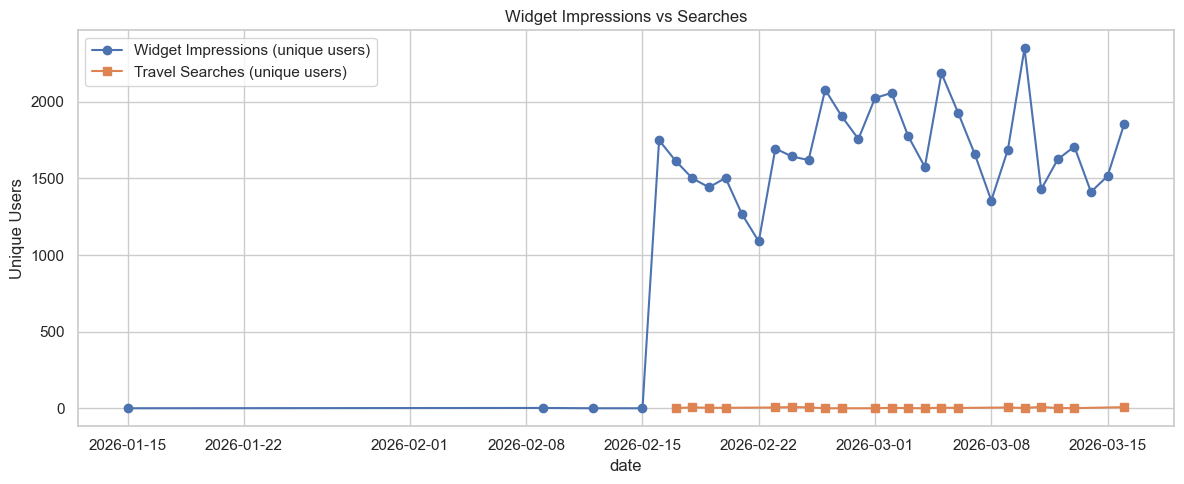

In [22]:
df_copy = df.copy()
df_copy['date'] = df_copy['timestamp'].dt.date

impressions = df_copy[df_copy['event'] == 'Embed Widget Viewed'].groupby('date')['anonymous_id'].nunique()
searches = df_copy[df_copy['event'] == 'Travel Searched'].groupby('date')['anonymous_id'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
impressions.plot(ax=ax, label='Widget Impressions (unique users)', marker='o')
searches.plot(ax=ax, label='Travel Searches (unique users)', marker='s')
ax.set_title('Widget Impressions vs Searches')
ax.set_ylabel('Unique Users')
ax.legend()
plt.tight_layout()
plt.show()

## Investigating CDN domain events

In [23]:
# Events from cdn.* referring domains
cdn_events = df[df['referring_domain'].str.startswith('cdn.', na=False)]
print(f"Total events from cdn.* domains: {len(cdn_events):,}")
print()
print("CDN domains breakdown:")
print(cdn_events['referring_domain'].value_counts())
print()
print("Event types from CDN domains:")
print(cdn_events['event'].value_counts())
print()
print("Sample CDN events - key columns:")
cdn_events[['event', 'page_url', 'page_path', 'referrer', 'referring_domain',
            'utm_source', 'utm_campaign', 'utm_term',
            'domain', 'variant', 'user_agent', 'anonymous_id', 'user_id']].head(15)

Total events from cdn.* domains: 162

CDN domains breakdown:
referring_domain
cdn.mycoloradoparks.com    126
cdn.skimag.com              36
Name: count, dtype: int64

Event types from CDN domains:
event
Loaded a Page          81
Embed Widget Viewed    81
Name: count, dtype: int64

Sample CDN events - key columns:


,event,page_url,page_path,referrer,referring_domain,utm_source,utm_campaign,utm_term,domain,variant,user_agent,anonymous_id,user_id
42757,Loaded a Page,https://travel.outsideonline.com/embed?query=Snowmass+Village&lat=39.2085&ln...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,None,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42758,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Snowmass+Village&lat=39.2085&ln...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,b,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42759,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Aspen&lat=39.1911&lng=-106.8175...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,a,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42760,Loaded a Page,https://travel.outsideonline.com/embed?query=Aspen&lat=39.1911&lng=-106.8175...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,None,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42761,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Snowmass+Village&lat=39.2085&ln...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,a,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42762,Loaded a Page,https://travel.outsideonline.com/embed?query=Snowmass+Village&lat=39.2085&ln...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,None,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42765,Loaded a Page,https://travel.outsideonline.com/embed?query=Aspen&lat=39.1911&lng=-106.8175...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,None,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42766,Loaded a Page,https://travel.outsideonline.com/embed?query=Steamboat+Springs&lat=40.485&ln...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,None,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42767,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Aspen&lat=39.1911&lng=-106.8175...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com,a,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, l...",c46d92d8-7a0b-4d35-9215-8a10ba251483,None
42768,Embed Widget Viewed,https://travel.outsideonline.com/embed?query=Steamboat+Springs&lat=40.485&ln...,/embed,https://cdn.mycoloradoparks.com/,cdn.mycoloradoparks.com,National Park Trips,"5 Best Colorado Mountain Towns, According to a Local",None,travel.outsideonline.com

## Investigating user_id formats

In [ ]:
import re

users_with_id = df[df['user_id'].notna()].copy()
unique_ids = users_with_id['user_id'].unique()
print(f"Total events with user_id: {len(users_with_id):,}")
print(f"Unique user_ids: {len(unique_ids)}")
print()

# Classify each user_id
uuid_pattern = re.compile(r'^[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}$', re.I)
email_pattern = re.compile(r'^[^@]+@[^@]+\.[^@]+$')

emails = [uid for uid in unique_ids if email_pattern.match(str(uid))]
uuids = [uid for uid in unique_ids if uuid_pattern.match(str(uid))]
other = [uid for uid in unique_ids if uid not in emails and uid not in uuids]

print(f"Email-format IDs: {len(emails)}")
for e in emails:
    print(f"  {e}")
print()
print(f"UUID-format IDs: {len(uuids)}")
for u in uuids:
    print(f"  {u}")
print()
if other:
    print(f"Other format IDs: {len(other)}")
    for o in other:
        print(f"  {o}")
print()

# Which event types do email vs UUID users fire?
print("Events by email-format users:")
print(users_with_id[users_with_id['user_id'].isin(emails)]['event'].value_counts())
print()
print("Events by UUID-format users:")
print(users_with_id[users_with_id['user_id'].isin(uuids)]['event'].value_counts())

In [24]:
# Are CDN events from the same anonymous users as non-CDN events?
# (i.e., are these real users who also appear on the main site?)
cdn_users = set(cdn_events['anonymous_id'].unique())
non_cdn = df[~df['referring_domain'].str.startswith('cdn.', na=True)]
non_cdn_users = set(non_cdn['anonymous_id'].unique())
overlap = cdn_users & non_cdn_users
print(f"CDN-only users: {len(cdn_users - non_cdn_users)}")
print(f"Users on both CDN and non-CDN: {len(overlap)}")
print(f"Non-CDN only users: {len(non_cdn_users - cdn_users)}")
print()

# What does the full referrer URL look like for CDN events?
print("Referrer URLs for CDN events:")
for url in cdn_events['referrer'].dropna().unique()[:10]:
    print(f"  {url}")

CDN-only users: 0
Users on both CDN and non-CDN: 6
Non-CDN only users: 46372

Referrer URLs for CDN events:
  https://cdn.mycoloradoparks.com/
  https://cdn.skimag.com/
